In [38]:
from pick_env.utils import save_states, load_states, load_actions
from robot_grasping_sim.env.states import State, InternalState
import matplotlib.pyplot as plt
import numpy as np
import torch

# states = load_states("state_cache.npy", "cpu")
# states = states[1:]
# target_motions = np.load("motion_cache.npy")

folder = "20240904-194033"
states = load_states(f"data/recorded_trajectory/real_trajectory/{folder}/states.npy", "cpu")
actions = load_actions(f"data/recorded_trajectory/real_trajectory/{folder}/actions.npy", "cpu")
target_motions = torch.stack(actions).permute(1,0,2).detach().cpu().numpy()

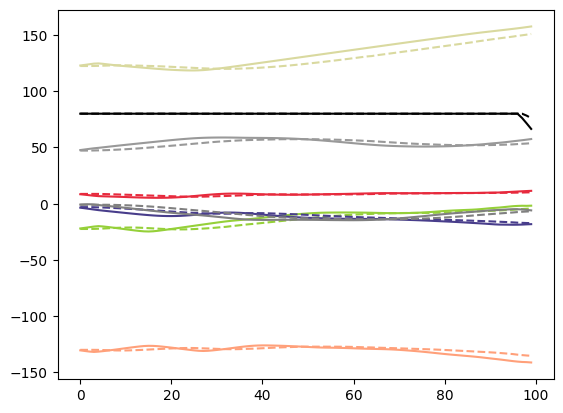

In [39]:
real_motions = []
for s in states:
    s:State
    real_motions.append(torch.concat([s.robot_joint_positions,s.robot_tcp_opening.reshape(-1,1)], dim=-1))

real_motions = torch.stack(real_motions, dim=0)
colors = [[0.90588235, 0.16470588, 0.23921569],
          [0.58431373, 0.81568627, 0.22352941],
          [0.28235294, 0.23921569, 0.54509804],
          [1.        , 0.62745098, 0.47843137],
          [0.50196078, 0.50196078, 0.50196078],
          [0.85098039, 0.85098039, 0.62352941],
          [0.6       , 0.6       , 0.6       ],
          [0.0, 0.0, 0.0]]
env_idx = 0
for env_idx in range(1):
    for j in range(8):
        # if j==6: continue
        if j==7:
            plt.plot(np.arange(real_motions.shape[0]), 1000*target_motions[env_idx,:,j], "-", color=colors[j], label=f"{j}_des")
            plt.plot(np.arange(real_motions.shape[0]), 2000*real_motions[:,env_idx,j].cpu().numpy(), "--",color=colors[j], label=f"{j}_real")
        else:
            plt.plot(np.arange(real_motions.shape[0]), 180/np.pi*target_motions[env_idx,:,j], "-", color=colors[j], label=f"{j}_des")
            plt.plot(np.arange(real_motions.shape[0]), 180/np.pi*real_motions[:,env_idx,j].cpu().numpy(), "--",color=colors[j], label=f"{j}_real")
    # plt.legend()
    plt.show()

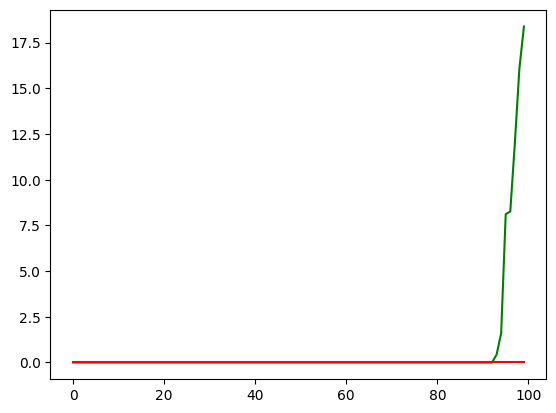

In [33]:
tactile_forces_l = []
tactile_forces_r = []
for s in states:
    s:State
    tactile_forces_l.append(s.sum_forces[0])
    tactile_forces_r.append(s.sum_forces[1])

tactile_forces_l = torch.stack(tactile_forces_l, dim=0)
tactile_forces_r = torch.stack(tactile_forces_r, dim=0)
env_idx = 0
for env_idx in range(1):
    f_l = tactile_forces_l[:,env_idx].norm(dim=-1)
    f_r = tactile_forces_r[:,env_idx].norm(dim=-1)
    plt.plot(np.arange(f_l.shape[0]), f_l.cpu().numpy(), color="green")
    plt.plot(np.arange(f_r.shape[0]), f_r.cpu().numpy(), color="red")
    plt.show()